# 06 - Embedding Noise Ablation

## Objective

The Mini-NOVIC decoder has already demonstrated:

- 100% exact-match accuracy on held-out CLIP text embeddings.
- 85% exact-match accuracy on the controlled zero-shot image test set.

The decoder was trained only from clean CLIP text embeddings.

This notebook investigates whether perturbing the text embeddings during training
improves transfer to CLIP image embeddings.

Three conditions are considered:

### A0 - Clean embeddings

No training noise.

This baseline was completed in Notebook 04 and achieved:

- Text validation accuracy: 100%
- Zero-shot image accuracy: 85%

### A1 - Gaussian noise + L2 renormalization

A random Gaussian vector is added to each text embedding:

e_noisy = normalize(e + sigma * epsilon)

where:

epsilon ~ N(0, I)

The resulting embedding is renormalized to unit length.

### A2 - NOVIC-style mixed noise

Training uses a mixture of:

- Gaussian perturbation
- Uniform-angle perturbation

For the angular component, a text embedding is rotated in a random orthogonal
direction while preserving its unit norm.

The NOVIC paper reports an approximately:

85% Gaussian / 15% uniform-angle

mixture, with uniform-angle perturbations sampled between approximately
45 and 75 degrees.

## Experimental rule

Everything except the embedding-noise method remains fixed:

- same CLIP text embeddings
- same train-validation split
- same vocabulary
- same decoder architecture
- same optimizer
- same number of epochs
- same controlled image test set

This allows the effect of embedding noise to be studied directly.

In [3]:
import sys
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import TensorDataset, DataLoader

from PIL import Image

print("Python:", sys.version)
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Python: 3.13.16 (main, Oct  1 2026, 15:40:24) [GCC 13.3.0]
PyTorch: 2.11.0+cpu
CUDA available: False


In [4]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

Using device: cpu


## 1. Load the existing Mini-NOVIC experiment

The cached CLIP text embeddings, clean decoder checkpoint, controlled image
dataset, and experiment outputs from earlier notebooks are reused.

In [5]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [6]:
DRIVE_ROOT = Path(
    "/content/drive/MyDrive/mini_novic_storage"
)

EMBEDDING_CACHE = (
    DRIVE_ROOT
    / "embeddings"
    / "text_embedding_dataset"
    / "clip_text_embeddings.pt"
)

A0_CHECKPOINT = (
    DRIVE_ROOT
    / "checkpoints"
    / "full_decoder_training"
    / "best_full_decoder.pt"
)

IMAGE_TEST_DIR = (
    DRIVE_ROOT
    / "datasets"
    / "image_transfer_test"
)

CHECKPOINT_DIR = (
    DRIVE_ROOT
    / "checkpoints"
    / "noise_ablation"
)

RESULT_DIR = (
    DRIVE_ROOT
    / "results"
    / "noise_ablation"
)

CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Embedding cache:", EMBEDDING_CACHE)
print("A0 checkpoint  :", A0_CHECKPOINT)
print("Image test dir :", IMAGE_TEST_DIR)
print("Results dir    :", RESULT_DIR)

Embedding cache: /content/drive/MyDrive/mini_novic_storage/embeddings/text_embedding_dataset/clip_text_embeddings.pt
A0 checkpoint  : /content/drive/MyDrive/mini_novic_storage/checkpoints/full_decoder_training/best_full_decoder.pt
Image test dir : /content/drive/MyDrive/mini_novic_storage/datasets/image_transfer_test
Results dir    : /content/drive/MyDrive/mini_novic_storage/results/noise_ablation


# Load cached text embeddings

In [7]:
cache = torch.load(
    EMBEDDING_CACHE,
    map_location="cpu"
)

embeddings = cache["embeddings"]
noun_texts = cache["noun_text"]
splits = cache["split"]

print("Embedding shape:", embeddings.shape)
print("CLIP model:", cache["model_name"])
print("Pretrained:", cache["pretrained"])

print(
    "Mean embedding norm:",
    embeddings.norm(dim=-1).mean().item()
)

Embedding shape: torch.Size([2500, 512])
CLIP model: ViT-B-32
Pretrained: laion2b_s34b_b79k
Mean embedding norm: 1.0


# Recover vocabulary from the clean checkpoint

In [8]:
a0_checkpoint = torch.load(
    A0_CHECKPOINT,
    map_location="cpu"
)

vocab = a0_checkpoint["vocab"]
token_to_id = a0_checkpoint["token_to_id"]
id_to_token = a0_checkpoint["id_to_token"]

PAD_ID = a0_checkpoint["pad_id"]
EOS_ID = a0_checkpoint["eos_id"]

VOCAB_SIZE = len(vocab)

CLIP_DIM = a0_checkpoint["clip_dim"]
HIDDEN_DIM = a0_checkpoint["hidden_dim"]
PREFIX_LEN = a0_checkpoint["prefix_len"]

NUM_LAYERS = a0_checkpoint["num_layers"]
NUM_HEADS = a0_checkpoint["num_heads"]

MAX_SEQ_LEN = a0_checkpoint["max_seq_len"]

print("Vocabulary size:", VOCAB_SIZE)
print("CLIP dimension :", CLIP_DIM)
print("Hidden size    :", HIDDEN_DIM)
print("Prefix length  :", PREFIX_LEN)
print("Maximum length :", MAX_SEQ_LEN)

Vocabulary size: 58
CLIP dimension : 512
Hidden size    : 256
Prefix length  : 4
Maximum length : 4


# Rebuild targets exactly as before

In [9]:
def encode_noun(noun):

    token_ids = [
        token_to_id[word]
        for word in noun.split()
    ]

    token_ids.append(EOS_ID)

    return token_ids

In [10]:
def pad_sequence(sequence):

    sequence = sequence[
        :MAX_SEQ_LEN
    ]

    padding_needed = (
        MAX_SEQ_LEN
        - len(sequence)
    )

    return (
        sequence
        + [PAD_ID] * padding_needed
    )

In [11]:
def decode_tokens(token_ids):

    words = []

    for token_id in token_ids:

        if token_id == EOS_ID:
            break

        if token_id == PAD_ID:
            continue

        words.append(
            id_to_token[token_id]
        )

    return " ".join(words)

In [12]:
target_sequences = torch.tensor(
    [
        pad_sequence(
            encode_noun(noun)
        )
        for noun in noun_texts
    ],
    dtype=torch.long
)

print(
    "Target shape:",
    target_sequences.shape
)

Target shape: torch.Size([2500, 4])


# Restore train/validation split

In [13]:
train_mask = torch.tensor(
    [
        split == "train"
        for split in splits
    ],
    dtype=torch.bool
)

val_mask = torch.tensor(
    [
        split == "val"
        for split in splits
    ],
    dtype=torch.bool
)

X_train = embeddings[train_mask]
y_train = target_sequences[train_mask]

X_val = embeddings[val_mask]
y_val = target_sequences[val_mask]

val_nouns = [
    noun
    for noun, split in zip(
        noun_texts,
        splits
    )
    if split == "val"
]

print("Training:", X_train.shape)
print("Validation:", X_val.shape)

Training: torch.Size([2000, 512])
Validation: torch.Size([500, 512])


# DataLoaders

In [14]:
BATCH_SIZE = 64

train_dataset = TensorDataset(
    X_train,
    y_train
)

val_dataset = TensorDataset(
    X_val,
    y_val
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=128,
    shuffle=False
)

# 2. A1 — Normalized Gaussian embedding noise

The first perturbation is intentionally simple.

For every clean unit text embedding e:

e_noisy = normalize(e + sigma * epsilon)

where epsilon is sampled independently from a standard Gaussian distribution.

The final normalization is essential because the CLIP embeddings used by the
decoder are unit vectors.

This experiment tests whether simply making the decoder less sensitive to the
exact text embedding location can improve image transfer.

In [15]:
def add_gaussian_noise(
    embeddings,
    sigma
):

    noise = torch.randn_like(
        embeddings
    )

    noisy = (
        embeddings
        + sigma * noise
    )

    noisy = F.normalize(
        noisy,
        dim=-1
    )

    return noisy

## Verify Gaussian noise preserves norm

In [16]:
test_embeddings = X_train[:128].to(
    device
)

for sigma in [
    0.01,
    0.03,
    0.05,
    0.10
]:

    noisy = add_gaussian_noise(
        test_embeddings,
        sigma
    )

    norms = noisy.norm(
        dim=-1
    )

    print(
        f"sigma={sigma:.2f} | "
        f"mean norm={norms.mean().item():.6f}"
    )

sigma=0.01 | mean norm=1.000000
sigma=0.03 | mean norm=1.000000
sigma=0.05 | mean norm=1.000000
sigma=0.10 | mean norm=1.000000


## Measure how much Gaussian noise rotates the embedding

In [17]:
@torch.no_grad()
def angular_distance_degrees(
    original,
    perturbed
):

    cosine = (
        original
        * perturbed
    ).sum(dim=-1)

    cosine = torch.clamp(
        cosine,
        -1.0,
        1.0
    )

    angle = torch.acos(
        cosine
    )

    return torch.rad2deg(
        angle
    )

Now inspect several sigmas:

In [18]:
sigma_records = []

test_embeddings = F.normalize(
    X_train[:1000].to(device),
    dim=-1
)

for sigma in [
    0.01,
    0.03,
    0.05,
    0.075,
    0.10,
    0.15
]:

    noisy = add_gaussian_noise(
        test_embeddings,
        sigma
    )

    angles = angular_distance_degrees(
        test_embeddings,
        noisy
    )

    sigma_records.append({
        "sigma":
            sigma,

        "mean_angle":
            angles.mean().item(),

        "std_angle":
            angles.std().item(),

        "min_angle":
            angles.min().item(),

        "max_angle":
            angles.max().item()
    })

sigma_df = pd.DataFrame(
    sigma_records
)

display(sigma_df)

,sigma,mean_angle,std_angle,min_angle,max_angle
0,0.010,12.741167,0.402014,11.515089,14.231083
1,0.030,34.113174,1.189646,30.646936,38.105721
2,0.050,48.556358,1.707514,42.101788,54.267654
3,0.075,59.483952,2.060435,53.318138,65.686943
4,0.100,66.289688,2.220835,59.880623,74.254272
5,0.150,73.507530,2.400853,66.824326,82.873955


## Plot sigma against angular change

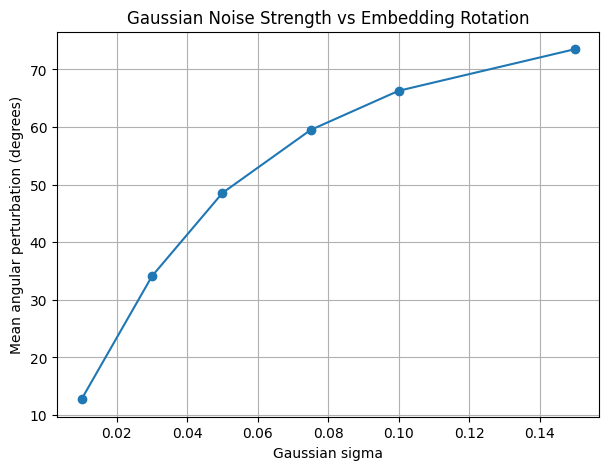

In [19]:
plt.figure(
    figsize=(7, 5)
)

plt.plot(
    sigma_df["sigma"],
    sigma_df["mean_angle"],
    marker="o"
)

plt.xlabel(
    "Gaussian sigma"
)

plt.ylabel(
    "Mean angular perturbation (degrees)"
)

plt.title(
    "Gaussian Noise Strength vs Embedding Rotation"
)

plt.grid(True)

plt.show()

# 3. Uniform-angle noise

Unlike elementwise Gaussian noise, uniform-angle noise explicitly controls the
angular distance between the original and perturbed embeddings.

For a unit embedding e, a random unit vector orthogonal to e is first constructed.

The perturbed vector is then:

e' = cos(theta)e + sin(theta)u_perp

where u_perp is orthogonal to e.

Therefore:

||e'|| = 1

and the angular distance between e and e' is exactly theta.

The NOVIC paper reports sampling theta approximately uniformly between
45 and 75 degrees for this component.

In [20]:
def add_uniform_angle_noise(
    embeddings,
    min_angle_deg=45.0,
    max_angle_deg=75.0
):

    embeddings = F.normalize(
        embeddings,
        dim=-1
    )

    # -----------------------------------
    # Random directions
    # -----------------------------------

    random_direction = torch.randn_like(
        embeddings
    )

    # -----------------------------------
    # Remove component parallel to e
    # -----------------------------------

    parallel_component = (
        random_direction
        * embeddings
    ).sum(
        dim=-1,
        keepdim=True
    )

    orthogonal = (
        random_direction
        - parallel_component
        * embeddings
    )

    # -----------------------------------
    # Normalize orthogonal direction
    # -----------------------------------

    orthogonal = F.normalize(
        orthogonal,
        dim=-1
    )

    # -----------------------------------
    # Random rotation angles
    # -----------------------------------

    batch_size = embeddings.size(0)

    angles_deg = torch.empty(
        batch_size,
        1,
        device=embeddings.device
    ).uniform_(
        min_angle_deg,
        max_angle_deg
    )

    angles_rad = torch.deg2rad(
        angles_deg
    )

    # -----------------------------------
    # Rotate
    # -----------------------------------

    perturbed = (
        torch.cos(angles_rad)
        * embeddings
        +
        torch.sin(angles_rad)
        * orthogonal
    )

    perturbed = F.normalize(
        perturbed,
        dim=-1
    )

    return perturbed

## Verify angular-noise geometry

In [21]:
test_embeddings = F.normalize(
    X_train[:1000].to(device),
    dim=-1
)

angle_noisy = add_uniform_angle_noise(
    test_embeddings,
    min_angle_deg=45,
    max_angle_deg=75
)

angles = angular_distance_degrees(
    test_embeddings,
    angle_noisy
)

print(
    "Mean output norm:",
    angle_noisy.norm(
        dim=-1
    ).mean().item()
)

print(
    "Minimum angle:",
    angles.min().item()
)

print(
    "Maximum angle:",
    angles.max().item()
)

print(
    "Mean angle:",
    angles.mean().item()
)

Mean output norm: 1.0
Minimum angle: 45.11219024658203
Maximum angle: 74.95486450195312
Mean angle: 59.87614822387695


# 4. Mixed NOVIC-style perturbation

For the paper-inspired mixed condition, each training embedding independently
selects one of two perturbations:

- 85% probability: Gaussian perturbation
- 15% probability: uniform-angle perturbation

The angular branch uses rotations between 45 and 75 degrees.

The Gaussian strength remains configurable so that the perturbation can be studied
rather than hard-coded invisibly.

In [22]:
def add_novic_style_noise(
    embeddings,
    gaussian_sigma=0.10,
    gaussian_probability=0.85,
    min_angle_deg=45.0,
    max_angle_deg=75.0
):

    batch_size = embeddings.size(0)

    # Start with Gaussian perturbed copies
    output = add_gaussian_noise(
        embeddings,
        gaussian_sigma
    )

    # Decide which examples receive
    # angular perturbation instead.
    use_angle = (
        torch.rand(
            batch_size,
            device=embeddings.device
        )
        >
        gaussian_probability
    )

    num_angle = (
        use_angle.sum().item()
    )

    if num_angle > 0:

        output[
            use_angle
        ] = add_uniform_angle_noise(
            embeddings[
                use_angle
            ],
            min_angle_deg,
            max_angle_deg
        )

    output = F.normalize(
        output,
        dim=-1
    )

    return output

## Verify mixed-noise norm

In [23]:
mixed_noisy = add_novic_style_noise(
    test_embeddings,
    gaussian_sigma=0.10
)

print(
    "Mean norm:",
    mixed_noisy.norm(
        dim=-1
    ).mean().item()
)

angles = angular_distance_degrees(
    test_embeddings,
    mixed_noisy
)

print(
    "Mean angular change:",
    angles.mean().item()
)

print(
    "Minimum:",
    angles.min().item()
)

print(
    "Maximum:",
    angles.max().item()
)

Mean norm: 1.0
Mean angular change: 64.93402862548828
Minimum: 45.172611236572266
Maximum: 74.7713394165039


# Recreate the working decoder

In [24]:
def build_attention_mask(
    prefix_len,
    token_len,
    device
):

    total_len = (
        prefix_len
        + token_len
    )

    mask = torch.full(
        (total_len, total_len),
        float("-inf"),
        device=device
    )

    mask[
        :prefix_len,
        :prefix_len
    ] = 0

    for i in range(token_len):

        row = prefix_len + i

        mask[
            row,
            :prefix_len + i + 1
        ] = 0

    return mask

In [25]:
class MiniNOVICDecoder(nn.Module):

    def __init__(
        self,
        clip_dim,
        vocab_size,
        hidden_dim=256,
        prefix_len=4,
        max_seq_len=4,
        num_layers=4,
        num_heads=4,
        dropout=0.1,
    ):

        super().__init__()

        self.hidden_dim = hidden_dim
        self.prefix_len = prefix_len
        self.max_seq_len = max_seq_len

        self.prefix_mapper = nn.Linear(
            clip_dim,
            prefix_len * hidden_dim
        )

        self.token_embedding = nn.Embedding(
            vocab_size,
            hidden_dim
        )

        self.position_embedding = nn.Embedding(
            prefix_len + max_seq_len,
            hidden_dim
        )

        transformer_layer = (
            nn.TransformerEncoderLayer(
                d_model=hidden_dim,
                nhead=num_heads,
                dim_feedforward=hidden_dim * 4,
                dropout=dropout,
                activation="gelu",
                batch_first=True,
                norm_first=True,
            )
        )

        self.transformer = nn.TransformerEncoder(
            transformer_layer,
            num_layers=num_layers
        )

        self.output_projection = nn.Linear(
            hidden_dim,
            vocab_size
        )

    def forward(
        self,
        clip_embeddings,
        token_ids
    ):

        batch_size = (
            clip_embeddings.size(0)
        )

        prefix = self.prefix_mapper(
            clip_embeddings
        )

        prefix = prefix.view(
            batch_size,
            self.prefix_len,
            self.hidden_dim
        )

        token_vectors = self.token_embedding(
            token_ids
        )

        x = torch.cat(
            [
                prefix,
                token_vectors
            ],
            dim=1
        )

        total_len = x.size(1)

        positions = torch.arange(
            total_len,
            device=x.device
        )

        x = (
            x
            + self.position_embedding(
                positions
            ).unsqueeze(0)
        )

        mask = build_attention_mask(
            self.prefix_len,
            token_ids.size(1),
            x.device
        )

        x = self.transformer(
            x,
            mask=mask
        )

        prediction_states = x[
            :,
            self.prefix_len - 1:,
            :
        ]

        logits = self.output_projection(
            prediction_states
        )

        return logits

# Create fresh model function
Very important: A1 and A2 need independent fresh models.

Do not continue training the A0 model.

In [26]:
def create_decoder():

    model = MiniNOVICDecoder(
        clip_dim=CLIP_DIM,
        vocab_size=VOCAB_SIZE,
        hidden_dim=HIDDEN_DIM,
        prefix_len=PREFIX_LEN,
        max_seq_len=MAX_SEQ_LEN,
        num_layers=NUM_LAYERS,
        num_heads=NUM_HEADS,
        dropout=0.1,
    )

    return model.to(device)

## Loss

In [27]:
criterion = nn.CrossEntropyLoss(
    ignore_index=PAD_ID
)

In [28]:
def compute_decoder_loss(
    model,
    clip_embeddings,
    target_tokens,
    criterion
):

    token_inputs = (
        target_tokens[:, :-1]
    )

    logits = model(
        clip_embeddings,
        token_inputs
    )

    loss = criterion(
        logits.reshape(
            -1,
            logits.size(-1)
        ),
        target_tokens.reshape(-1)
    )

    return loss, logits

## Validation
Notice something important:

Do not add noise during validation.

We want to evaluate on the original clean text embeddings.

In [29]:
@torch.no_grad()
def evaluate_text(
    model,
    loader
):

    model.eval()

    total_loss = 0
    total_correct = 0
    total_valid = 0

    for batch_X, batch_y in loader:

        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)

        loss, logits = (
            compute_decoder_loss(
                model,
                batch_X,
                batch_y,
                criterion
            )
        )

        total_loss += (
            loss.item()
            * batch_X.size(0)
        )

        predictions = logits.argmax(
            dim=-1
        )

        valid_mask = (
            batch_y != PAD_ID
        )

        correct = (
            predictions == batch_y
        ) & valid_mask

        total_correct += (
            correct.sum().item()
        )

        total_valid += (
            valid_mask.sum().item()
        )

    return (
        total_loss
        / len(loader.dataset),

        total_correct
        / total_valid
    )

# Make one reusable training function
This is much better than copying the training loop three times.

In [30]:
def train_noise_model(
    experiment_name,
    noise_function,
    num_epochs=30,
    learning_rate=3e-4,
    weight_decay=1e-4
):

    model = create_decoder()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )

    best_val_loss = float("inf")

    best_path = (
        CHECKPOINT_DIR
        / f"{experiment_name}_best.pt"
    )

    history = []

    for epoch in range(
        1,
        num_epochs + 1
    ):

        model.train()

        total_loss = 0
        total_correct = 0
        total_valid = 0

        for batch_X, batch_y in train_loader:

            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            # ============================
            # APPLY TRAINING NOISE HERE
            # ============================

            noisy_X = noise_function(
                batch_X
            )

            optimizer.zero_grad()

            loss, logits = (
                compute_decoder_loss(
                    model,
                    noisy_X,
                    batch_y,
                    criterion
                )
            )

            loss.backward()

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                1.0
            )

            optimizer.step()

            total_loss += (
                loss.item()
                * batch_X.size(0)
            )

            predictions = logits.argmax(
                dim=-1
            )

            valid_mask = (
                batch_y != PAD_ID
            )

            correct = (
                predictions == batch_y
            ) & valid_mask

            total_correct += (
                correct.sum().item()
            )

            total_valid += (
                valid_mask.sum().item()
            )

        train_loss = (
            total_loss
            / len(train_dataset)
        )

        train_acc = (
            total_correct
            / total_valid
        )

        # Clean validation
        val_loss, val_acc = (
            evaluate_text(
                model,
                val_loader
            )
        )

        if val_loss < best_val_loss:

            best_val_loss = val_loss

            torch.save(
                {
                    "model_state_dict":
                        model.state_dict(),

                    "experiment":
                        experiment_name,

                    "epoch":
                        epoch,

                    "val_loss":
                        val_loss,

                    "val_token_accuracy":
                        val_acc,
                },
                best_path
            )

            marker = " ← best"

        else:
            marker = ""

        history.append({
            "epoch":
                epoch,

            "train_loss":
                train_loss,

            "train_token_accuracy":
                train_acc,

            "val_loss":
                val_loss,

            "val_token_accuracy":
                val_acc
        })

        print(
            f"{experiment_name} | "
            f"Epoch {epoch:02d}/{num_epochs} | "
            f"Train Loss {train_loss:.4f} | "
            f"Train Acc {train_acc*100:.2f}% | "
            f"Val Loss {val_loss:.4f} | "
            f"Val Acc {val_acc*100:.2f}%"
            f"{marker}"
        )

    history_df = pd.DataFrame(
        history
    )

    history_df.to_csv(
        RESULT_DIR
        / f"{experiment_name}_history.csv",
        index=False
    )

    return (
        model,
        best_path,
        history_df
    )

# Train A1

In [31]:
A1_SIGMA = 0.05

In [32]:
def a1_noise(x):

    return add_gaussian_noise(
        x,
        sigma=A1_SIGMA
    )

In [33]:
a1_model, a1_path, a1_history = (
    train_noise_model(
        experiment_name="A1_gaussian",
        noise_function=a1_noise,
        num_epochs=30
    )
)

/tmp/ipykernel_533/169747943.py:48: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


A1_gaussian | Epoch 01/30 | Train Loss 2.1256 | Train Acc 51.51% | Val Loss 1.8330 | Val Acc 55.86% ← best
A1_gaussian | Epoch 02/30 | Train Loss 1.7919 | Train Acc 56.37% | Val Loss 1.7687 | Val Acc 58.02% ← best
A1_gaussian | Epoch 03/30 | Train Loss 1.7423 | Train Acc 57.07% | Val Loss 1.6460 | Val Acc 60.99% ← best
A1_gaussian | Epoch 04/30 | Train Loss 1.5604 | Train Acc 60.43% | Val Loss 1.2833 | Val Acc 65.05% ← best
A1_gaussian | Epoch 05/30 | Train Loss 1.2834 | Train Acc 63.90% | Val Loss 0.9221 | Val Acc 72.79% ← best
A1_gaussian | Epoch 06/30 | Train Loss 0.9329 | Train Acc 72.09% | Val Loss 0.5430 | Val Acc 86.67% ← best
A1_gaussian | Epoch 07/30 | Train Loss 0.7262 | Train Acc 77.57% | Val Loss 0.3571 | Val Acc 89.91% ← best
A1_gaussian | Epoch 08/30 | Train Loss 0.5427 | Train Acc 82.55% | Val Loss 0.1915 | Val Acc 95.77% ← best
A1_gaussian | Epoch 09/30 | Train Loss 0.4523 | Train Acc 84.80% | Val Loss 0.1432 | Val Acc 97.66% ← best
A1_gaussian | Epoch 10/30 | Train Los

## Plot A1 training

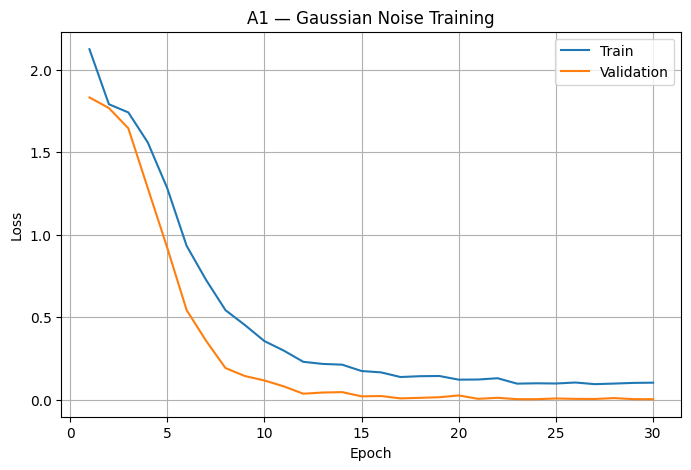

In [34]:
plt.figure(
    figsize=(8, 5)
)

plt.plot(
    a1_history["epoch"],
    a1_history["train_loss"],
    label="Train"
)

plt.plot(
    a1_history["epoch"],
    a1_history["val_loss"],
    label="Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "A1 — Gaussian Noise Training"
)

plt.legend()
plt.grid(True)

plt.show()

# Train A2

In [35]:
A2_GAUSSIAN_SIGMA = 0.10

In [36]:
def a2_noise(x):

    return add_novic_style_noise(
        x,
        gaussian_sigma=A2_GAUSSIAN_SIGMA,
        gaussian_probability=0.85,
        min_angle_deg=45,
        max_angle_deg=75
    )

In [37]:
a2_model, a2_path, a2_history = (
    train_noise_model(
        experiment_name="A2_novic_style",
        noise_function=a2_noise,
        num_epochs=30
    )
)

/tmp/ipykernel_533/169747943.py:48: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


A2_novic_style | Epoch 01/30 | Train Loss 2.1443 | Train Acc 50.63% | Val Loss 1.8428 | Val Acc 56.76% ← best
A2_novic_style | Epoch 02/30 | Train Loss 1.8330 | Train Acc 55.70% | Val Loss 1.7902 | Val Acc 57.66% ← best
A2_novic_style | Epoch 03/30 | Train Loss 1.8009 | Train Acc 56.31% | Val Loss 1.7602 | Val Acc 55.86% ← best
A2_novic_style | Epoch 04/30 | Train Loss 1.7670 | Train Acc 56.37% | Val Loss 1.7037 | Val Acc 58.56% ← best
A2_novic_style | Epoch 05/30 | Train Loss 1.7568 | Train Acc 56.46% | Val Loss 1.6198 | Val Acc 64.14% ← best
A2_novic_style | Epoch 06/30 | Train Loss 1.6926 | Train Acc 57.88% | Val Loss 1.4158 | Val Acc 64.23% ← best
A2_novic_style | Epoch 07/30 | Train Loss 1.4898 | Train Acc 60.68% | Val Loss 1.0026 | Val Acc 72.34% ← best
A2_novic_style | Epoch 08/30 | Train Loss 1.3485 | Train Acc 62.43% | Val Loss 0.8413 | Val Acc 75.50% ← best
A2_novic_style | Epoch 09/30 | Train Loss 1.2238 | Train Acc 64.95% | Val Loss 0.6797 | Val Acc 78.29% ← best
A2_novic_s

# Load the best A1 and A2 checkpoints

In [38]:
def load_noise_checkpoint(
    checkpoint_path
):

    model = create_decoder()

    checkpoint = torch.load(
        checkpoint_path,
        map_location=device
    )

    model.load_state_dict(
        checkpoint[
            "model_state_dict"
        ]
    )

    model.eval()

    print(
        checkpoint["experiment"],
        "| epoch:",
        checkpoint["epoch"],
        "| val loss:",
        checkpoint["val_loss"]
    )

    return model, checkpoint

In [39]:
a1_model, a1_checkpoint = (
    load_noise_checkpoint(
        a1_path
    )
)

a2_model, a2_checkpoint = (
    load_noise_checkpoint(
        a2_path
    )
)

A1_gaussian | epoch: 30 | val loss: 0.002663482462987304
A2_novic_style | epoch: 28 | val loss: 0.04875541833043098


/tmp/ipykernel_533/169747943.py:48: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


# Greedy generation

In [40]:
@torch.no_grad()
def generate_greedy(
    model,
    clip_embedding,
    max_length=MAX_SEQ_LEN
):

    model.eval()

    if clip_embedding.dim() == 1:

        clip_embedding = (
            clip_embedding.unsqueeze(0)
        )

    clip_embedding = (
        clip_embedding.to(device)
    )

    generated = []

    for _ in range(max_length):

        if len(generated) == 0:

            token_inputs = torch.empty(
                (1, 0),
                dtype=torch.long,
                device=device
            )

        else:

            token_inputs = torch.tensor(
                [generated],
                dtype=torch.long,
                device=device
            )

        logits = model(
            clip_embedding,
            token_inputs
        )

        next_token = (
            logits[:, -1, :]
            .argmax(dim=-1)
            .item()
        )

        if (
            next_token == EOS_ID
            or next_token == PAD_ID
        ):
            break

        generated.append(
            next_token
        )

    return generated

## Exact text generation accuracy

In [41]:
@torch.no_grad()
def evaluate_text_generation(
    model,
    embeddings,
    expected_nouns
):

    predictions = []

    for i in range(
        len(embeddings)
    ):

        ids = generate_greedy(
            model,
            embeddings[i]
        )

        prediction = decode_tokens(
            ids
        )

        predictions.append(
            prediction
        )

    results = pd.DataFrame({
        "expected":
            expected_nouns,

        "generated":
            predictions
    })

    results["correct"] = (
        results["expected"]
        ==
        results["generated"]
    )

    accuracy = (
        results["correct"]
        .mean()
    )

    return accuracy, results

A1:

In [42]:
a1_text_accuracy, a1_text_results = (
    evaluate_text_generation(
        a1_model,
        X_val,
        val_nouns
    )
)

print(
    "A1 text exact accuracy:",
    f"{a1_text_accuracy*100:.2f}%"
)

A1 text exact accuracy: 99.80%


A2:

In [43]:
a2_text_accuracy, a2_text_results = (
    evaluate_text_generation(
        a2_model,
        X_val,
        val_nouns
    )
)

print(
    "A2 text exact accuracy:",
    f"{a2_text_accuracy*100:.2f}%"
)

A2 text exact accuracy: 98.60%


# Now load the image encoder

In [44]:
!pip install -q open_clip_torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.1 MB/s eta 0:00:00


In [45]:
import open_clip

In [46]:
MODEL_NAME = cache["model_name"]
PRETRAINED = cache["pretrained"]

print(MODEL_NAME)
print(PRETRAINED)

ViT-B-32
laion2b_s34b_b79k


In [47]:
clip_model, _, preprocess = (
    open_clip.create_model_and_transforms(
        MODEL_NAME,
        pretrained=PRETRAINED
    )
)

clip_model = (
    clip_model
    .to(device)
    .eval()
)

for parameter in clip_model.parameters():
    parameter.requires_grad = False

open_clip_model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

open_clip_model.safetensors: downloading bytes:           |  0.00B            

## Recover the same 40-image test set

In [48]:
image_extensions = {
    ".jpg",
    ".jpeg",
    ".png",
    ".webp"
}

records = []

for noun_dir in IMAGE_TEST_DIR.iterdir():

    if not noun_dir.is_dir():
        continue

    for image_path in noun_dir.iterdir():

        if (
            image_path.suffix.lower()
            in image_extensions
        ):

            records.append({
                "image_path":
                    str(image_path),

                "expected":
                    noun_dir.name
            })

image_df = pd.DataFrame(
    records
)

print(
    "Images:",
    len(image_df)
)

print(
    "Classes:",
    image_df[
        "expected"
    ].nunique()
)

Images: 38
Classes: 10


## Image encoding function

In [49]:
@torch.no_grad()
def encode_image(
    image_path
):

    image = Image.open(
        image_path
    ).convert("RGB")

    image_tensor = (
        preprocess(image)
        .unsqueeze(0)
        .to(device)
    )

    embedding = (
        clip_model.encode_image(
            image_tensor
        )
    )

    embedding = F.normalize(
        embedding,
        dim=-1
    )

    return embedding

## Evaluate a decoder on the image set

In [50]:
@torch.no_grad()
def evaluate_images(
    model,
    image_df
):

    predictions = []

    for _, row in image_df.iterrows():

        embedding = encode_image(
            row["image_path"]
        )

        ids = generate_greedy(
            model,
            embedding
        )

        noun = decode_tokens(
            ids
        )

        predictions.append(
            noun
        )

    results = image_df.copy()

    results["generated"] = (
        predictions
    )

    results["correct"] = (
        results["expected"]
        ==
        results["generated"]
    )

    accuracy = (
        results["correct"]
        .mean()
    )

    return accuracy, results

## Evaluate A1 on images

In [51]:
a1_image_accuracy, a1_image_results = (
    evaluate_images(
        a1_model,
        image_df
    )
)

print(
    "A1 Gaussian image accuracy:",
    f"{a1_image_accuracy*100:.2f}%"
)

A1 Gaussian image accuracy: 84.21%


## Evaluate A2 on images

In [52]:
a2_image_accuracy, a2_image_results = (
    evaluate_images(
        a2_model,
        image_df
    )
)

print(
    "A2 NOVIC-style image accuracy:",
    f"{a2_image_accuracy*100:.2f}%"
)

A2 NOVIC-style image accuracy: 86.84%


# Build the final ablation table

In [53]:
A0_TEXT_ACCURACY = 1.00
A0_IMAGE_ACCURACY = 0.89

In [54]:
ablation_results = pd.DataFrame([
    {
        "experiment":
            "A0",

        "noise":
            "None",

        "text_accuracy":
            A0_TEXT_ACCURACY,

        "image_accuracy":
            A0_IMAGE_ACCURACY
    },

    {
        "experiment":
            "A1",

        "noise":
            f"Gaussian sigma={A1_SIGMA}",

        "text_accuracy":
            a1_text_accuracy,

        "image_accuracy":
            a1_image_accuracy
    },

    {
        "experiment":
            "A2",

        "noise":
            "85% Gaussian + 15% angular",

        "text_accuracy":
            a2_text_accuracy,

        "image_accuracy":
            a2_image_accuracy
    }
])

ablation_results[
    "text_accuracy_percent"
] = (
    ablation_results[
        "text_accuracy"
    ] * 100
)

ablation_results[
    "image_accuracy_percent"
] = (
    ablation_results[
        "image_accuracy"
    ] * 100
)

display(
    ablation_results
)

,experiment,noise,text_accuracy,image_accuracy,text_accuracy_percent,image_accuracy_percent
0,A0,None,1.000,0.890000,100.0,89.000000
1,A1,Gaussian sigma=0.05,0.998,0.842105,99.8,84.210526
2,A2,85% Gaussian + 15% angular,0.986,0.868421,98.6,86.842105


## Save it

In [55]:
ablation_results.to_csv(
    RESULT_DIR
    / "noise_ablation_summary.csv",
    index=False
)

In [56]:
a1_image_results.to_csv(
    RESULT_DIR
    / "A1_image_predictions.csv",
    index=False
)

a2_image_results.to_csv(
    RESULT_DIR
    / "A2_image_predictions.csv",
    index=False
)

## Compare predictions image-by-image

In [57]:
comparison = pd.DataFrame({
    "image_path":
        image_df["image_path"],

    "expected":
        image_df["expected"],

    "A1":
        a1_image_results[
            "generated"
        ],

    "A2":
        a2_image_results[
            "generated"
        ]
})

In [58]:
A0_RESULTS_PATH = (
    DRIVE_ROOT
    / "results"
    / "zero_shot_image_transfer"
    / "zero_shot_image_predictions.csv"
)

if A0_RESULTS_PATH.exists():

    a0_results = pd.read_csv(
        A0_RESULTS_PATH
    )

    comparison.insert(
        2,
        "A0",
        a0_results[
            "generated"
        ]
    )

In [59]:
display(
    comparison
)

,image_path,expected,A0,A1,A2
0,/content/drive/MyDrive/mini_novic_storage/data...,cat,cat,cat,cat
1,/content/drive/MyDrive/mini_novic_storage/data...,cat,cat,cat,cat
2,/content/drive/MyDrive/mini_novic_storage/data...,cat,cat,chair,cat
3,/content/drive/MyDrive/mini_novic_storage/data...,cat,cat,cat,cat
4,/content/drive/MyDrive/mini_novic_storage/data...,dog,dog,dog,dog
5,/content/drive/MyDrive/mini_novic_storage/data...,dog,dog,dog,dog
6,/content/drive/MyDrive/mini_novic_storage/data...,dog,dog,bed,dog
7,/content/drive/MyDrive/mini_novic_storage/data...,dog,dog,dog,dog
8,/content/drive/MyDrive/mini_novic_storage/data...,fire truck,fire truck,fire truck,fire truck
9,/content/drive/MyDrive/mini_novic_storage/data...,fire truck,fire truck,fire truck,fire truck


# Per-class comparison

In [60]:
def per_class_accuracy(
    results,
    name
):

    table = (
        results
        .groupby(
            "expected"
        )["correct"]
        .mean()
        .reset_index()
    )

    table = table.rename(
        columns={
            "correct":
                name
        }
    )

    return table

In [61]:
a1_per_class = per_class_accuracy(
    a1_image_results,
    "A1"
)

a2_per_class = per_class_accuracy(
    a2_image_results,
    "A2"
)

per_class_comparison = (
    a1_per_class
    .merge(
        a2_per_class,
        on="expected"
    )
)

display(
    per_class_comparison
)

,expected,A1,A2
0,airplane,1.000000,1.00
1,bus,1.000000,0.75
2,cat,0.750000,1.00
3,chair,0.750000,0.75
4,coffee mug,1.000000,1.00
5,dog,0.750000,1.00
6,fire truck,1.000000,1.00
7,helicopter,1.000000,1.00
8,laptop,0.500000,1.00
9,truck,0.666667,0.00


# 5. Gaussian Noise Strength Sweep

The first Gaussian experiment used sigma = 0.05 and achieved the best image
accuracy among the initial ablations.

However, a single sigma value does not tell us whether this noise level is optimal.

This section performs a controlled Gaussian noise-strength sweep.

For each sigma value:

1. A fresh decoder is initialized.
2. Training uses Gaussian-perturbed text embeddings.
3. Validation is performed on clean text embeddings.
4. Exact autoregressive text accuracy is measured.
5. The same corrected image test set is evaluated.
6. The mean angular perturbation caused by the sigma value is recorded.

Everything except sigma remains fixed.

The purpose is to identify the trade-off between:

- too little noise, which may leave the decoder overly specialized to text embeddings;
- moderate noise, which may improve cross-modal robustness;
- excessive noise, which may destroy class-specific semantic information.

In [62]:
SWEEP_SIGMAS = [
    0.00,
    0.01,
    0.03,
    0.05,
    0.075,
    0.10,
    0.15,
]

print("Sweep values:", SWEEP_SIGMAS)

Sweep values: [0.0, 0.01, 0.03, 0.05, 0.075, 0.1, 0.15]


## Helper to estimate mean angular perturbation

In [63]:
@torch.no_grad()
def estimate_gaussian_angle(
    sigma,
    num_samples=1000
):

    sample = X_train[
        :min(
            num_samples,
            len(X_train)
        )
    ].to(device)

    sample = F.normalize(
        sample,
        dim=-1
    )

    if sigma == 0:

        return 0.0

    noisy = add_gaussian_noise(
        sample,
        sigma=sigma
    )

    angles = angular_distance_degrees(
        sample,
        noisy
    )

    return angles.mean().item()

Test:

In [64]:
for sigma in SWEEP_SIGMAS:

    mean_angle = estimate_gaussian_angle(
        sigma
    )

    print(
        f"sigma={sigma:0.3f} "
        f"-> mean angle={mean_angle:0.2f}°"
    )

sigma=0.000 -> mean angle=0.00°
sigma=0.010 -> mean angle=12.73°
sigma=0.030 -> mean angle=34.14°
sigma=0.050 -> mean angle=48.56°
sigma=0.075 -> mean angle=59.48°
sigma=0.100 -> mean angle=66.28°
sigma=0.150 -> mean angle=73.46°


## Reproducible seed reset
This is important.

If every experiment starts from a different random initialization, some accuracy difference might come from initialization rather than sigma.

In [65]:
def reset_random_seeds(seed=SEED):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():

        torch.cuda.manual_seed_all(
            seed
        )

## Generic Gaussian noise function creator

In [66]:
def make_gaussian_noise_function(
    sigma
):

    def noise_function(x):

        if sigma == 0:

            return x

        return add_gaussian_noise(
            x,
            sigma=sigma
        )

    return noise_function

## Run the full sweep

In [67]:
sweep_records = []

sweep_models = {}
sweep_text_results = {}
sweep_image_results = {}

for sigma in SWEEP_SIGMAS:

    print(
        "\n"
        + "=" * 70
    )

    print(
        f"GAUSSIAN SWEEP | sigma={sigma}"
    )

    print(
        "=" * 70
    )

    # -----------------------------------
    # Reset seed for fair initialization
    # -----------------------------------

    reset_random_seeds(
        SEED
    )

    # -----------------------------------
    # Noise function
    # -----------------------------------

    noise_fn = (
        make_gaussian_noise_function(
            sigma
        )
    )

    # -----------------------------------
    # Train fresh decoder
    # -----------------------------------

    experiment_name = (
        f"sweep_gaussian_"
        f"{sigma:.3f}"
        .replace(".", "p")
    )

    model, checkpoint_path, history = (
        train_noise_model(
            experiment_name=experiment_name,
            noise_function=noise_fn,
            num_epochs=30
        )
    )

    # -----------------------------------
    # Load best checkpoint
    # -----------------------------------

    model, checkpoint = (
        load_noise_checkpoint(
            checkpoint_path
        )
    )

    # -----------------------------------
    # Clean text generation accuracy
    # -----------------------------------

    text_accuracy, text_results = (
        evaluate_text_generation(
            model,
            X_val,
            val_nouns
        )
    )

    # -----------------------------------
    # Image generation accuracy
    # -----------------------------------

    image_accuracy, image_results = (
        evaluate_images(
            model,
            image_df
        )
    )

    # -----------------------------------
    # Mean perturbation angle
    # -----------------------------------

    mean_angle = (
        estimate_gaussian_angle(
            sigma
        )
    )

    # -----------------------------------
    # Save outputs
    # -----------------------------------

    text_results.to_csv(
        RESULT_DIR
        / (
            f"sweep_sigma_"
            f"{sigma:.3f}"
            .replace(".", "p")
            + "_text.csv"
        ),
        index=False
    )

    image_results.to_csv(
        RESULT_DIR
        / (
            f"sweep_sigma_"
            f"{sigma:.3f}"
            .replace(".", "p")
            + "_images.csv"
        ),
        index=False
    )

    # -----------------------------------
    # Record summary
    # -----------------------------------

    sweep_records.append({
        "sigma":
            sigma,

        "mean_angle_deg":
            mean_angle,

        "best_epoch":
            checkpoint["epoch"],

        "best_val_loss":
            checkpoint["val_loss"],

        "val_token_accuracy":
            checkpoint[
                "val_token_accuracy"
            ],

        "text_exact_accuracy":
            text_accuracy,

        "image_exact_accuracy":
            image_accuracy,
    })

    sweep_models[sigma] = model
    sweep_text_results[sigma] = (
        text_results
    )
    sweep_image_results[sigma] = (
        image_results
    )

    print(
        f"\nRESULT sigma={sigma:.3f}"
    )

    print(
        f"Mean angle: "
        f"{mean_angle:.2f}°"
    )

    print(
        f"Text exact accuracy: "
        f"{text_accuracy*100:.2f}%"
    )

    print(
        f"Image exact accuracy: "
        f"{image_accuracy*100:.2f}%"
    )


GAUSSIAN SWEEP | sigma=0.0


/tmp/ipykernel_533/169747943.py:48: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


sweep_gaussian_0p000 | Epoch 01/30 | Train Loss 2.1962 | Train Acc 50.47% | Val Loss 1.8016 | Val Acc 57.66% ← best
sweep_gaussian_0p000 | Epoch 02/30 | Train Loss 1.7078 | Train Acc 57.61% | Val Loss 1.6567 | Val Acc 62.43% ← best
sweep_gaussian_0p000 | Epoch 03/30 | Train Loss 1.3186 | Train Acc 67.95% | Val Loss 0.8532 | Val Acc 77.57% ← best
sweep_gaussian_0p000 | Epoch 04/30 | Train Loss 0.5190 | Train Acc 87.14% | Val Loss 0.2249 | Val Acc 94.59% ← best
sweep_gaussian_0p000 | Epoch 05/30 | Train Loss 0.1497 | Train Acc 96.80% | Val Loss 0.0533 | Val Acc 99.01% ← best
sweep_gaussian_0p000 | Epoch 06/30 | Train Loss 0.0445 | Train Acc 99.28% | Val Loss 0.0116 | Val Acc 99.91% ← best
sweep_gaussian_0p000 | Epoch 07/30 | Train Loss 0.0165 | Train Acc 99.68% | Val Loss 0.0034 | Val Acc 100.00% ← best
sweep_gaussian_0p000 | Epoch 08/30 | Train Loss 0.0081 | Train Acc 99.95% | Val Loss 0.0318 | Val Acc 98.92%
sweep_gaussian_0p000 | Epoch 09/30 | Train Loss 0.0095 | Train Acc 99.77% | Va

/tmp/ipykernel_533/169747943.py:48: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


sweep_gaussian_0p010 | Epoch 01/30 | Train Loss 2.1972 | Train Acc 50.02% | Val Loss 1.8092 | Val Acc 56.76% ← best
sweep_gaussian_0p010 | Epoch 02/30 | Train Loss 1.7202 | Train Acc 57.97% | Val Loss 1.6641 | Val Acc 60.00% ← best
sweep_gaussian_0p010 | Epoch 03/30 | Train Loss 1.4081 | Train Acc 65.45% | Val Loss 0.9094 | Val Acc 79.10% ← best
sweep_gaussian_0p010 | Epoch 04/30 | Train Loss 0.5458 | Train Acc 86.62% | Val Loss 0.2813 | Val Acc 93.96% ← best
sweep_gaussian_0p010 | Epoch 05/30 | Train Loss 0.1790 | Train Acc 96.19% | Val Loss 0.0816 | Val Acc 97.93% ← best
sweep_gaussian_0p010 | Epoch 06/30 | Train Loss 0.0782 | Train Acc 98.29% | Val Loss 0.0287 | Val Acc 99.55% ← best
sweep_gaussian_0p010 | Epoch 07/30 | Train Loss 0.0294 | Train Acc 99.55% | Val Loss 0.0158 | Val Acc 99.73% ← best
sweep_gaussian_0p010 | Epoch 08/30 | Train Loss 0.0166 | Train Acc 99.66% | Val Loss 0.0181 | Val Acc 99.37%
sweep_gaussian_0p010 | Epoch 09/30 | Train Loss 0.0186 | Train Acc 99.48% | Val

...

sweep_gaussian_0p075 | Epoch 01/30 | Train Loss 2.2199 | Train Acc 49.73% | Val Loss 1.8433 | Val Acc 55.86% ← best
sweep_gaussian_0p075 | Epoch 02/30 | Train Loss 1.8113 | Train Acc 56.10% | Val Loss 1.7824 | Val Acc 56.31% ← best
sweep_gaussian_0p075 | Epoch 03/30 | Train Loss 1.7883 | Train Acc 56.04% | Val Loss 1.7404 | Val Acc 58.02% ← best
sweep_gaussian_0p075 | Epoch 04/30 | Train Loss 1.7544 | Train Acc 56.42% | Val Loss 1.6379 | Val Acc 61.80% ← best
sweep_gaussian_0p075 | Epoch 05/30 | Train Loss 1.6692 | Train Acc 58.27% | Val Loss 1.3212 | Val Acc 68.29% ← best
sweep_gaussian_0p075 | Epoch 06/30 | Train Loss 1.5671 | Train Acc 60.02% | Val Loss 1.2405 | Val Acc 61.62% ← best
sweep_gaussian_0p075 | Epoch 07/30 | Train Loss 1.2864 | Train Acc 63.58% | Val Loss 0.7384 | Val Acc 77.57% ← best
sweep_gaussian_0p075 | Epoch 08/30 | Train Loss 1.0261 | Train Acc 69.55% | Val Loss 0.5144 | Val Acc 86.67% ← best
sweep_gaussian_0p075 | Epoch 09/30 | Train Loss 0.8463 | Train Acc 74.21

/tmp/ipykernel_533/169747943.py:48: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


sweep_gaussian_0p100 | Epoch 01/30 | Train Loss 2.2229 | Train Acc 49.68% | Val Loss 1.8502 | Val Acc 55.86% ← best
sweep_gaussian_0p100 | Epoch 02/30 | Train Loss 1.8212 | Train Acc 56.06% | Val Loss 1.7982 | Val Acc 56.22% ← best
sweep_gaussian_0p100 | Epoch 03/30 | Train Loss 1.8069 | Train Acc 55.83% | Val Loss 1.7749 | Val Acc 57.66% ← best
sweep_gaussian_0p100 | Epoch 04/30 | Train Loss 1.7865 | Train Acc 55.97% | Val Loss 1.7069 | Val Acc 58.83% ← best
sweep_gaussian_0p100 | Epoch 05/30 | Train Loss 1.7601 | Train Acc 56.51% | Val Loss 1.6581 | Val Acc 63.96% ← best
sweep_gaussian_0p100 | Epoch 06/30 | Train Loss 1.7117 | Train Acc 57.57% | Val Loss 1.4517 | Val Acc 63.78% ← best
sweep_gaussian_0p100 | Epoch 07/30 | Train Loss 1.6088 | Train Acc 58.83% | Val Loss 1.1958 | Val Acc 70.18% ← best
sweep_gaussian_0p100 | Epoch 08/30 | Train Loss 1.4406 | Train Acc 61.62% | Val Loss 0.8932 | Val Acc 79.64% ← best
sweep_gaussian_0p100 | Epoch 09/30 | Train Loss 1.2336 | Train Acc 65.29

/tmp/ipykernel_533/169747943.py:48: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


sweep_gaussian_0p150 | Epoch 01/30 | Train Loss 2.2256 | Train Acc 49.68% | Val Loss 1.8584 | Val Acc 55.86% ← best
sweep_gaussian_0p150 | Epoch 02/30 | Train Loss 1.8297 | Train Acc 55.99% | Val Loss 1.8154 | Val Acc 55.95% ← best
sweep_gaussian_0p150 | Epoch 03/30 | Train Loss 1.8216 | Train Acc 55.56% | Val Loss 1.8057 | Val Acc 55.86% ← best
sweep_gaussian_0p150 | Epoch 04/30 | Train Loss 1.8087 | Train Acc 55.79% | Val Loss 1.7560 | Val Acc 55.86% ← best
sweep_gaussian_0p150 | Epoch 05/30 | Train Loss 1.7944 | Train Acc 55.99% | Val Loss 1.7487 | Val Acc 59.82% ← best
sweep_gaussian_0p150 | Epoch 06/30 | Train Loss 1.7810 | Train Acc 55.99% | Val Loss 1.7023 | Val Acc 60.27% ← best
sweep_gaussian_0p150 | Epoch 07/30 | Train Loss 1.7768 | Train Acc 56.17% | Val Loss 1.6771 | Val Acc 60.72% ← best
sweep_gaussian_0p150 | Epoch 08/30 | Train Loss 1.7539 | Train Acc 56.80% | Val Loss 1.5880 | Val Acc 59.91% ← best
sweep_gaussian_0p150 | Epoch 09/30 | Train Loss 1.7026 | Train Acc 56.89

## Build the sweep summary table

In [68]:
sweep_df = pd.DataFrame(
    sweep_records
)

sweep_df[
    "text_accuracy_percent"
] = (
    sweep_df[
        "text_exact_accuracy"
    ] * 100
)

sweep_df[
    "image_accuracy_percent"
] = (
    sweep_df[
        "image_exact_accuracy"
    ] * 100
)

display(
    sweep_df
)

,sigma,mean_angle_deg,best_epoch,best_val_loss,val_token_accuracy,text_exact_accuracy,image_exact_accuracy,text_accuracy_percent,image_accuracy_percent
0,0.000,0.000000,30,0.000023,1.000000,1.000,0.894737,100.0,89.473684
1,0.010,12.748897,16,0.000066,1.000000,1.000,0.868421,100.0,86.842105
2,0.030,34.183800,29,0.000104,1.000000,1.000,0.815789,100.0,81.578947
3,0.050,48.557926,30,0.003684,0.999099,0.998,0.894737,99.8,89.473684
4,0.075,59.531185,29,0.009834,1.000000,1.000,0.868421,100.0,86.842105
5,0.100,66.199974,30,0.034623,0.993694,0.986,0.842105,98.6,84.210526
6,0.150,73.625656,30,0.203540,0.968468,0.930,0.815789,93.0,81.578947


In [69]:
sweep_df.to_csv(
    RESULT_DIR
    / "gaussian_noise_sweep_summary.csv",
    index=False
)

## Find the best sigma

In [70]:
best_row = (
    sweep_df
    .sort_values(
        "image_exact_accuracy",
        ascending=False
    )
    .iloc[0]
)

BEST_SIGMA = float(
    best_row["sigma"]
)

print(
    "Best sigma:",
    BEST_SIGMA
)

print(
    "Mean angle:",
    f"{best_row['mean_angle_deg']:.2f}°"
)

print(
    "Text accuracy:",
    f"{best_row['text_accuracy_percent']:.2f}%"
)

print(
    "Image accuracy:",
    f"{best_row['image_accuracy_percent']:.2f}%"
)

Best sigma: 0.0
Mean angle: 0.00°
Text accuracy: 100.00%
Image accuracy: 89.47%


## Plot image accuracy versus sigma

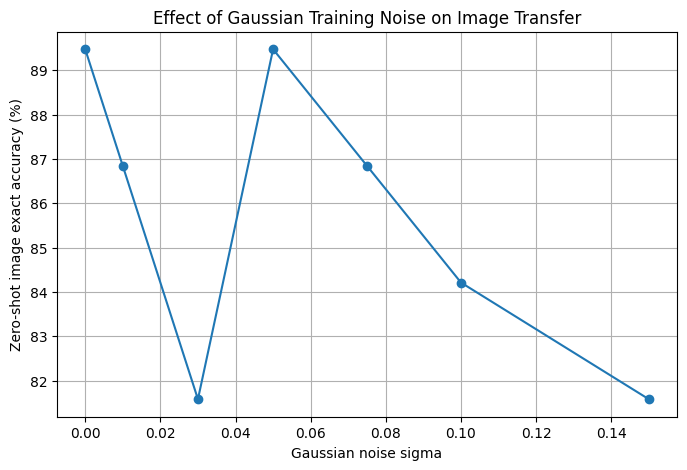

In [71]:
plt.figure(
    figsize=(8, 5)
)

plt.plot(
    sweep_df["sigma"],
    sweep_df[
        "image_accuracy_percent"
    ],
    marker="o"
)

plt.xlabel(
    "Gaussian noise sigma"
)

plt.ylabel(
    "Zero-shot image exact accuracy (%)"
)

plt.title(
    "Effect of Gaussian Training Noise on Image Transfer"
)

plt.grid(True)

plt.show()

## Plot image accuracy versus angular perturbation

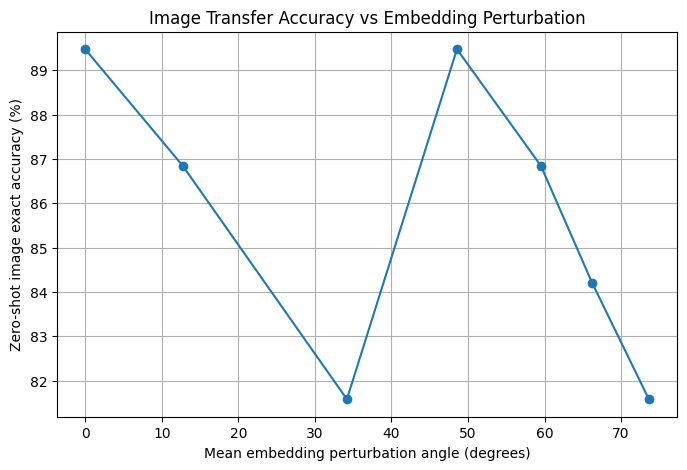

In [72]:
plt.figure(
    figsize=(8, 5)
)

plt.plot(
    sweep_df[
        "mean_angle_deg"
    ],
    sweep_df[
        "image_accuracy_percent"
    ],
    marker="o"
)

plt.xlabel(
    "Mean embedding perturbation angle (degrees)"
)

plt.ylabel(
    "Zero-shot image exact accuracy (%)"
)

plt.title(
    "Image Transfer Accuracy vs Embedding Perturbation"
)

plt.grid(True)

plt.show()

## Plot text and image accuracy together

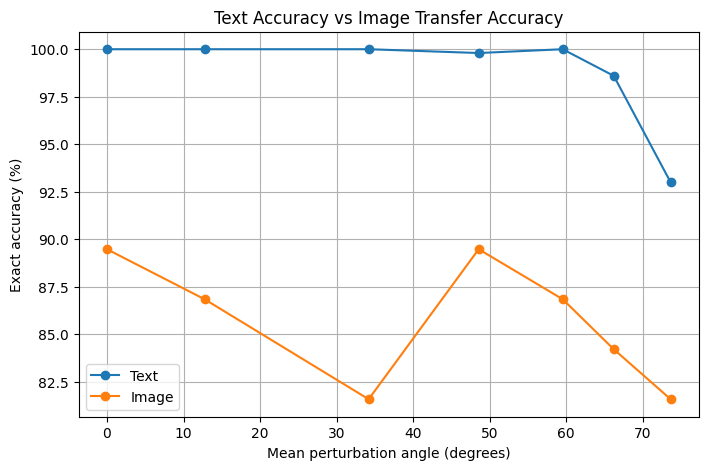

In [73]:
plt.figure(
    figsize=(8, 5)
)

plt.plot(
    sweep_df[
        "mean_angle_deg"
    ],
    sweep_df[
        "text_accuracy_percent"
    ],
    marker="o",
    label="Text"
)

plt.plot(
    sweep_df[
        "mean_angle_deg"
    ],
    sweep_df[
        "image_accuracy_percent"
    ],
    marker="o",
    label="Image"
)

plt.xlabel(
    "Mean perturbation angle (degrees)"
)

plt.ylabel(
    "Exact accuracy (%)"
)

plt.title(
    "Text Accuracy vs Image Transfer Accuracy"
)

plt.legend()
plt.grid(True)

plt.show()

## Per-class comparison across sigma

In [74]:
per_class_tables = []

for sigma in SWEEP_SIGMAS:

    results = (
        sweep_image_results[
            sigma
        ]
    )

    table = (
        results
        .groupby(
            "expected"
        )["correct"]
        .mean()
        .reset_index()
    )

    column_name = (
        f"sigma_{sigma:.3f}"
    )

    table = table.rename(
        columns={
            "correct":
                column_name
        }
    )

    per_class_tables.append(
        table
    )

In [75]:
from functools import reduce

sweep_per_class = reduce(
    lambda left, right:
        left.merge(
            right,
            on="expected"
        ),
    per_class_tables
)

display(
    sweep_per_class
)

,expected,sigma_0.000,sigma_0.010,sigma_0.030,sigma_0.050,sigma_0.075,sigma_0.100,sigma_0.150
0,airplane,1.000000,1.000000,1.000000,1.00,1.00,1.000000,1.000000
1,bus,1.000000,1.000000,1.000000,0.75,0.75,0.750000,0.500000
2,cat,1.000000,1.000000,1.000000,1.00,1.00,1.000000,0.500000
3,chair,0.250000,0.250000,0.000000,0.50,0.50,0.750000,1.000000
4,coffee mug,1.000000,1.000000,1.000000,1.00,0.50,0.500000,0.500000
5,dog,1.000000,1.000000,1.000000,1.00,1.00,1.000000,1.000000
6,fire truck,1.000000,1.000000,0.750000,0.75,1.00,1.000000,1.000000
7,helicopter,1.000000,1.000000,1.000000,1.00,1.00,1.000000,1.000000
8,laptop,1.000000,0.750000,1.000000,1.00,1.00,1.000000,1.000000
9,truck,0.666667,0.666667,0.333333,1.00,1.00,0.333333,0.666667


In [76]:
sweep_per_class.to_csv(
    RESULT_DIR
    / "gaussian_sweep_per_class.csv",
    index=False
)

## Compare the best Gaussian model against A2
After finding BEST_SIGMA:

In [77]:
best_gaussian_image_results = (
    sweep_image_results[
        BEST_SIGMA
    ]
)

In [78]:
best_vs_mixed = pd.DataFrame({
    "image_path":
        image_df[
            "image_path"
        ],

    "expected":
        image_df[
            "expected"
        ],

    "best_gaussian":
        best_gaussian_image_results[
            "generated"
        ],

    "mixed_A2":
        a2_image_results[
            "generated"
        ],
})

In [79]:
display(
    best_vs_mixed
)

,image_path,expected,best_gaussian,mixed_A2
0,/content/drive/MyDrive/mini_novic_storage/data...,cat,cat,cat
1,/content/drive/MyDrive/mini_novic_storage/data...,cat,cat,cat
2,/content/drive/MyDrive/mini_novic_storage/data...,cat,cat,cat
3,/content/drive/MyDrive/mini_novic_storage/data...,cat,cat,cat
4,/content/drive/MyDrive/mini_novic_storage/data...,dog,dog,dog
5,/content/drive/MyDrive/mini_novic_storage/data...,dog,dog,dog
6,/content/drive/MyDrive/mini_novic_storage/data...,dog,dog,dog
7,/content/drive/MyDrive/mini_novic_storage/data...,dog,dog,dog
8,/content/drive/MyDrive/mini_novic_storage/data...,fire truck,fire truck,fire truck
9,/content/drive/MyDrive/mini_novic_storage/data...,fire truck,fire truck,fire truck


# 6. Fair Gaussian vs Mixed-Noise Comparison

The previous experiments showed that Gaussian noise with sigma = 0.05 is one of
the strongest settings for the current Mini-NOVIC configuration.

The earlier mixed-noise experiment used a larger Gaussian strength
(sigma = 0.10), so it changed both:

- the noise formulation, and
- the overall perturbation strength.

This makes it difficult to determine whether the performance reduction came from
the angular component or simply from excessive noise.

This section performs a fairer comparison.

Two conditions are compared:

### G-best — Gaussian only

Gaussian noise with:

sigma = 0.05

### M-fair — Mixed noise

85% of samples:
Gaussian noise with sigma = 0.05

15% of samples:
uniform-angle rotation between 45 and 75 degrees

Everything else remains unchanged:

- same text embeddings
- same train/validation split
- same decoder
- same optimizer
- same number of epochs
- same image test set
- same random seed

The only new factor is the 15% angular-noise component.

In [80]:
FAIR_GAUSSIAN_SIGMA = 0.05
FAIR_GAUSSIAN_PROBABILITY = 0.85
FAIR_MIN_ANGLE = 45.0
FAIR_MAX_ANGLE = 75.0

In [81]:
def fair_mixed_noise(x):

    return add_novic_style_noise(
        x,
        gaussian_sigma=FAIR_GAUSSIAN_SIGMA,
        gaussian_probability=FAIR_GAUSSIAN_PROBABILITY,
        min_angle_deg=FAIR_MIN_ANGLE,
        max_angle_deg=FAIR_MAX_ANGLE
    )

## First inspect the geometry
Before training, let's verify what this mixed formulation actually does.

In [83]:
test_embeddings = F.normalize(
    X_train[:1000].to(device),
    dim=-1
)

fair_mixed = fair_mixed_noise(
    test_embeddings
)

fair_angles = angular_distance_degrees(
    test_embeddings,
    fair_mixed
)

print(
    "Mean norm:",
    fair_mixed.norm(
        dim=-1
    ).mean().item()
)

print(
    "Mean angle:",
    fair_angles.mean().item()
)

print(
    "Minimum angle:",
    fair_angles.min().item()
)

print(
    "Maximum angle:",
    fair_angles.max().item()
)

Mean norm: 1.0
Mean angle: 50.31536865234375
Minimum angle: 43.31819152832031
Maximum angle: 74.82269287109375


In [84]:
gaussian_only = add_gaussian_noise(
    test_embeddings,
    sigma=0.05
)

gaussian_angles = angular_distance_degrees(
    test_embeddings,
    gaussian_only
)

In [85]:
geometry_comparison = pd.DataFrame([
    {
        "method":
            "Gaussian sigma=0.05",

        "mean_angle":
            gaussian_angles.mean().item(),

        "std_angle":
            gaussian_angles.std().item(),

        "min_angle":
            gaussian_angles.min().item(),

        "max_angle":
            gaussian_angles.max().item(),
    },

    {
        "method":
            "85% Gaussian + 15% angular",

        "mean_angle":
            fair_angles.mean().item(),

        "std_angle":
            fair_angles.std().item(),

        "min_angle":
            fair_angles.min().item(),

        "max_angle":
            fair_angles.max().item(),
    },
])

display(
    geometry_comparison
)

,method,mean_angle,std_angle,min_angle,max_angle
0,Gaussian sigma=0.05,48.545719,1.714411,43.486462,53.894939
1,85% Gaussian + 15% angular,50.315369,5.897337,43.318192,74.822693


In [86]:
geometry_comparison.to_csv(
    RESULT_DIR
    / "fair_mixed_noise_geometry.csv",
    index=False
)

## Reset the seed
We want the fresh mixed model to start from the same initialization convention.

In [87]:
reset_random_seeds(
    SEED
)

## Train the fair mixed model
Use the same train_noise_model() function.

In [88]:
fair_mixed_model, fair_mixed_path, fair_mixed_history = (
    train_noise_model(
        experiment_name="A3_fair_mixed_sigma_0p05",
        noise_function=fair_mixed_noise,
        num_epochs=30
    )
)

/tmp/ipykernel_533/169747943.py:48: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


A3_fair_mixed_sigma_0p05 | Epoch 01/30 | Train Loss 2.2150 | Train Acc 50.20% | Val Loss 1.8301 | Val Acc 56.76% ← best
A3_fair_mixed_sigma_0p05 | Epoch 02/30 | Train Loss 1.8029 | Train Acc 56.17% | Val Loss 1.7664 | Val Acc 55.86% ← best
A3_fair_mixed_sigma_0p05 | Epoch 03/30 | Train Loss 1.7489 | Train Acc 56.58% | Val Loss 1.6590 | Val Acc 60.36% ← best
A3_fair_mixed_sigma_0p05 | Epoch 04/30 | Train Loss 1.6337 | Train Acc 59.84% | Val Loss 1.2929 | Val Acc 61.98% ← best
A3_fair_mixed_sigma_0p05 | Epoch 05/30 | Train Loss 1.2716 | Train Acc 65.34% | Val Loss 0.7827 | Val Acc 80.99% ← best
A3_fair_mixed_sigma_0p05 | Epoch 06/30 | Train Loss 0.9183 | Train Acc 71.69% | Val Loss 0.5125 | Val Acc 85.50% ← best
A3_fair_mixed_sigma_0p05 | Epoch 07/30 | Train Loss 0.7058 | Train Acc 78.38% | Val Loss 0.3027 | Val Acc 93.15% ← best
A3_fair_mixed_sigma_0p05 | Epoch 08/30 | Train Loss 0.5219 | Train Acc 83.74% | Val Loss 0.1875 | Val Acc 96.04% ← best
A3_fair_mixed_sigma_0p05 | Epoch 09/30 |

## Plot its training curve

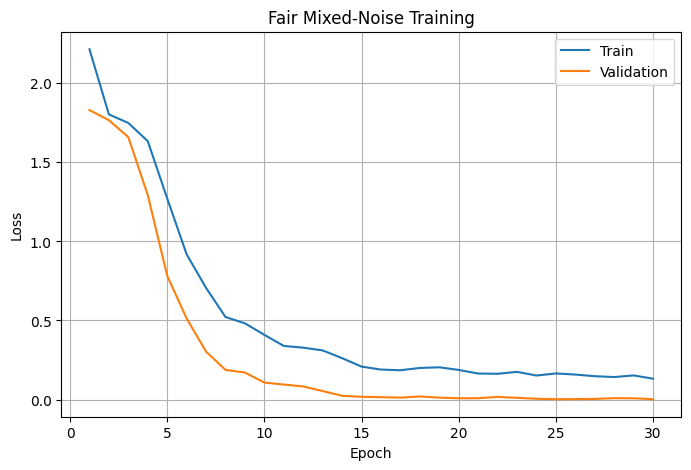

In [89]:
plt.figure(
    figsize=(8, 5)
)

plt.plot(
    fair_mixed_history["epoch"],
    fair_mixed_history["train_loss"],
    label="Train"
)

plt.plot(
    fair_mixed_history["epoch"],
    fair_mixed_history["val_loss"],
    label="Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Fair Mixed-Noise Training"
)

plt.legend()
plt.grid(True)

plt.show()

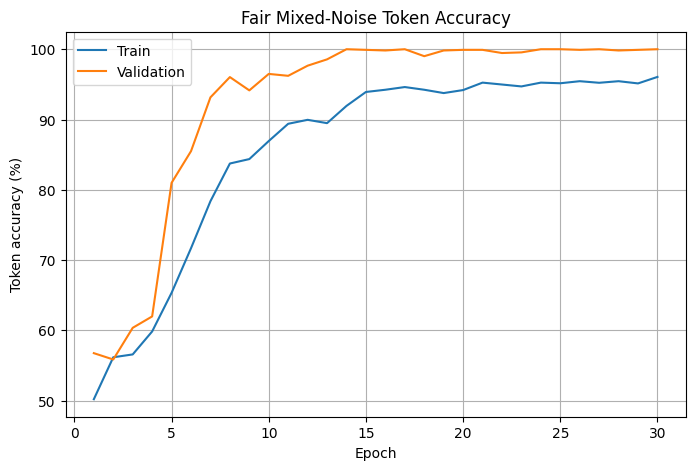

In [90]:
plt.figure(
    figsize=(8, 5)
)

plt.plot(
    fair_mixed_history["epoch"],
    fair_mixed_history[
        "train_token_accuracy"
    ] * 100,
    label="Train"
)

plt.plot(
    fair_mixed_history["epoch"],
    fair_mixed_history[
        "val_token_accuracy"
    ] * 100,
    label="Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Token accuracy (%)")

plt.title(
    "Fair Mixed-Noise Token Accuracy"
)

plt.legend()
plt.grid(True)

plt.show()

In [91]:
fair_mixed_model, fair_mixed_checkpoint = (
    load_noise_checkpoint(
        fair_mixed_path
    )
)

A3_fair_mixed_sigma_0p05 | epoch: 30 | val loss: 0.0020531311491504313


/tmp/ipykernel_533/169747943.py:48: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(


In [92]:
print(
    "Best epoch:",
    fair_mixed_checkpoint["epoch"]
)

print(
    "Best validation loss:",
    fair_mixed_checkpoint["val_loss"]
)

print(
    "Validation token accuracy:",
    fair_mixed_checkpoint[
        "val_token_accuracy"
    ]
)

Best epoch: 30
Best validation loss: 0.0020531311491504313
Validation token accuracy: 1.0


In [93]:
fair_mixed_text_accuracy, fair_mixed_text_results = (
    evaluate_text_generation(
        fair_mixed_model,
        X_val,
        val_nouns
    )
)

In [94]:
print(
    "Fair mixed text exact accuracy:",
    f"{fair_mixed_text_accuracy * 100:.2f}%"
)

Fair mixed text exact accuracy: 100.00%


In [95]:
fair_mixed_text_results.to_csv(
    RESULT_DIR
    / "A3_fair_mixed_text_predictions.csv",
    index=False
)

In [96]:
# ============================================================
# FAIR COMPARISON: Gaussian sigma=0.05 vs 85% Gaussian + 15% angular
# ============================================================

# 1. Evaluate fair mixed model on images
fair_mixed_image_accuracy, fair_mixed_image_results = evaluate_images(
    fair_mixed_model,
    image_df
)

# 2. Get Gaussian sigma=0.05 baseline from sweep
gaussian_005_row = sweep_df[sweep_df["sigma"] == 0.05].iloc[0]
gaussian_005_text_accuracy = gaussian_005_row["text_exact_accuracy"]
gaussian_005_image_accuracy = gaussian_005_row["image_exact_accuracy"]

gaussian_005_results = sweep_image_results[0.05]

# 3. Compact overall comparison
fair_comparison = pd.DataFrame([
    {
        "experiment": "Gaussian only",
        "sigma": 0.05,
        "angular_fraction": 0.00,
        "text_accuracy": gaussian_005_text_accuracy,
        "image_accuracy": gaussian_005_image_accuracy,
    },
    {
        "experiment": "85% Gaussian + 15% angular",
        "sigma": 0.05,
        "angular_fraction": 0.15,
        "text_accuracy": fair_mixed_text_accuracy,
        "image_accuracy": fair_mixed_image_accuracy,
    }
])

fair_comparison["text_accuracy_%"] = fair_comparison["text_accuracy"] * 100
fair_comparison["image_accuracy_%"] = fair_comparison["image_accuracy"] * 100

print("=== FAIR NOISE COMPARISON ===")
display(fair_comparison)

# 4. Compare predictions image-by-image
prediction_comparison = pd.DataFrame({
    "image_path": image_df["image_path"].values,
    "expected": image_df["expected"].values,
    "gaussian_0.05": gaussian_005_results["generated"].values,
    "fair_mixed": fair_mixed_image_results["generated"].values,
})

prediction_comparison["gaussian_correct"] = (
    prediction_comparison["expected"] == prediction_comparison["gaussian_0.05"]
)

prediction_comparison["mixed_correct"] = (
    prediction_comparison["expected"] == prediction_comparison["fair_mixed"]
)

# 5. Only cases changed by angular component
changed = prediction_comparison[
    prediction_comparison["gaussian_0.05"]
    != prediction_comparison["fair_mixed"]
].copy()

improved = changed[
    (~changed["gaussian_correct"]) & (changed["mixed_correct"])
]

regressed = changed[
    (changed["gaussian_correct"]) & (~changed["mixed_correct"])
]

print(f"\nFair mixed image accuracy: {fair_mixed_image_accuracy*100:.2f}%")
print(f"Changed predictions: {len(changed)}")
print(f"Improved by angular component: {len(improved)}")
print(f"Regressed by angular component: {len(regressed)}")

if len(changed) > 0:
    print("\nChanged cases:")
    display(changed)

# 6. Per-class comparison
gaussian_per_class = (
    gaussian_005_results
    .groupby("expected")["correct"]
    .mean()
    .reset_index(name="gaussian_0.05")
)

mixed_per_class = (
    fair_mixed_image_results
    .groupby("expected")["correct"]
    .mean()
    .reset_index(name="fair_mixed")
)

fair_per_class = gaussian_per_class.merge(
    mixed_per_class,
    on="expected"
)

fair_per_class["difference"] = (
    fair_per_class["fair_mixed"]
    - fair_per_class["gaussian_0.05"]
)

print("\nPer-class comparison:")
display(fair_per_class)

# 7. Save important outputs
fair_comparison.to_csv(
    RESULT_DIR / "fair_gaussian_vs_angular_comparison.csv",
    index=False
)

prediction_comparison.to_csv(
    RESULT_DIR / "fair_prediction_comparison.csv",
    index=False
)

fair_per_class.to_csv(
    RESULT_DIR / "fair_mixed_per_class.csv",
    index=False
)

fair_mixed_image_results.to_csv(
    RESULT_DIR / "A3_fair_mixed_image_predictions.csv",
    index=False
)

=== FAIR NOISE COMPARISON ===


,experiment,sigma,angular_fraction,text_accuracy,image_accuracy,text_accuracy_%,image_accuracy_%
0,Gaussian only,0.05,0.00,0.998,0.894737,99.8,89.473684
1,85% Gaussian + 15% angular,0.05,0.15,1.000,0.894737,100.0,89.473684



Fair mixed image accuracy: 89.47%
Changed predictions: 3
Improved by angular component: 1
Regressed by angular component: 1

Changed cases:


,image_path,expected,gaussian_0.05,fair_mixed,gaussian_correct,mixed_correct
11,/content/drive/MyDrive/mini_novic_storage/data...,fire truck,truck,fire truck,False,True
32,/content/drive/MyDrive/mini_novic_storage/data...,truck,truck,fire truck,True,False
35,/content/drive/MyDrive/mini_novic_storage/data...,bus,truck,fire truck,False,False



Per-class comparison:


,expected,gaussian_0.05,fair_mixed,difference
0,airplane,1.00,1.000000,0.000000
1,bus,0.75,0.750000,0.000000
2,cat,1.00,1.000000,0.000000
3,chair,0.50,0.500000,0.000000
4,coffee mug,1.00,1.000000,0.000000
5,dog,1.00,1.000000,0.000000
6,fire truck,0.75,1.000000,0.250000
7,helicopter,1.00,1.000000,0.000000
8,laptop,1.00,1.000000,0.000000
9,truck,1.00,0.666667,-0.333333


## Final Noise-Ablation Conclusion

The controlled Gaussian noise sweep showed that moderate Gaussian perturbation
can preserve strong text and image performance, while stronger perturbations
gradually degrade class-specific accuracy.

A fair comparison was then performed between:

- Gaussian noise with sigma = 0.05
- 85% Gaussian noise with sigma = 0.05 plus 15% uniform-angle noise

Both methods achieved the same zero-shot image exact-match accuracy of 89.47%.

The mixed-noise model slightly improved clean-text exact accuracy from 99.8% to
100%, but did not improve overall image accuracy.

At the class level, the angular component improved fire-truck recognition but
reduced truck recognition, indicating that it changed decision boundaries among
semantically related object categories rather than providing a consistent global
benefit.

Therefore, for the current small-scale Mini-NOVIC configuration, the 15% angular
component does not provide a measurable overall advantage over moderate Gaussian
noise alone.

This differs from the full NOVIC setting, where the authors report gains from
adding 15% uniform-angle noise. The difference is likely related to the much
larger training corpus, object vocabulary, model configuration, and embedding
setup used by the full method.